# First look: core vs ring, Edmonton and Calgary regions

**Internal working notebook — not for publication.** It charts the three committed
outputs as they stand, so we can see the shapes before any Phase 4 chart text is
written. Several figures here are still under open TODO items (noted at each chart).

Bases that hold for every chart below:
- **Region = 2025 board membership applied to all years** (13 EMRB members, 8 CMRB
  members; decision 8). Core = the city; ring = the other members.
- **Equalized assessment** for the tax-base split, never raw FIR assessment.
- **Nominal dollars** for per-capita series (no deflator yet — TODO).
- **Per-capita population** = StatCan 17-10-0155 July 1 estimates moved onto each
  year's boundaries (`population_asof`, decision 2026-10-03).

Rebuild: `.venv/bin/jupytext --sync notebooks/01_first_look.py` then
`.venv/bin/jupyter nbconvert --to notebook --execute --inplace notebooks/01_first_look.ipynb`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROC = ROOT / "data" / "processed"
share = pd.read_csv(PROC / "core_ring_share.csv")
transfers = pd.read_csv(PROC / "transfers_per_capita.csv")
spending = pd.read_csv(PROC / "spending_per_capita.csv")
annex = pd.read_csv(ROOT / "data" / "annexations.csv", parse_dates=["effective"])

# Reference palette (dataviz skill, light mode): slot 1 = core, slot 2 = ring.
CORE, RING = "#2a78d6", "#eb6834"
INK, MUTED, GRID = "#0b0b0b", "#52514e", "#e4e3df"
REGIONS = ["edmonton", "calgary"]
TITLE = {"edmonton": "Edmonton region (EMRB, 13)", "calgary": "Calgary region (CMRB, 8)"}

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 9, "axes.edgecolor": MUTED, "axes.labelcolor": MUTED,
    "xtick.color": MUTED, "ytick.color": MUTED, "axes.spines.top": False,
    "axes.spines.right": False, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.axisbelow": True, "lines.linewidth": 2, "legend.frameon": False,
})

# Only annexations between the core and a ring member move value across the
# core/ring line; ring-to-ring ones cancel inside the ring total.
core_annex = annex[annex.gainer.isin(REGIONS)]
core_annex[["effective", "gainer", "loser", "people"]]

,effective,gainer,loser,people
5,2005-01-01,calgary,rocky_view,38
6,2005-01-01,calgary,foothills,99
10,2007-01-01,calgary,rocky_view,619
23,2019-01-01,edmonton,leduc_county,542


In [2]:
def mark(ax, x, label, y=0.98):
    ax.axvline(x, color=MUTED, lw=0.8, ls=":", zorder=1)
    right = x > 2015  # late markers would run off the panel's right edge
    ax.text(x, y, f" {label} ", transform=ax.get_xaxis_transform(), fontsize=7,
            color=MUTED, va="top", ha="right" if right else "left")


def mark_core_annexations(ax, region, y=0.10):
    events = core_annex[core_annex.gainer == region].groupby("effective").loser.agg(list)
    for k, (date, losers) in enumerate(events.items()):
        names = " + ".join(l.replace("_", " ").title() for l in losers)
        mark(ax, date.year + (date.dayofyear - 1) / 365, f"annex. from {names}", y=y + 0.07 * k)

## 1. The tax-base split: core share of equalized non-residential assessment

Headline basis `nr` (non-residential; 1998–2004 reports print railway inside it).
`nr_linear` adds regulated linear property; `nr_all` adds machinery & equipment too.
x-axis is **taxation year** (= report year − 1). Taxation years 2007–2009 are missing:
those reports are scanned PDFs. Across that gap Edmonton's `nr_linear` rises while `nr`
barely moves — a composition effect (market NR more than doubled, regulated linear
grew ~25%), not a data break (TODO: caption it in Phase 4).

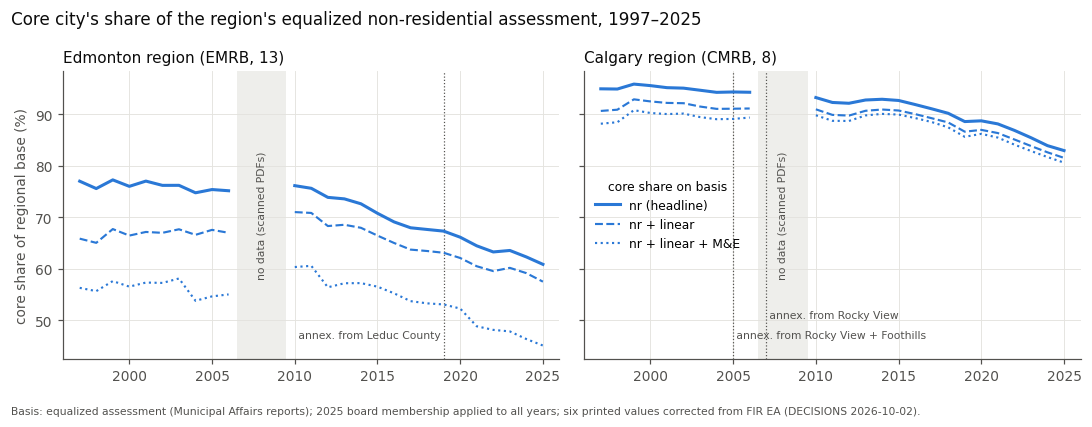

In [3]:
STYLE = {"nr": ("-", 2.0, "nr (headline)"), "nr_linear": ("--", 1.4, "nr + linear"),
         "nr_all": (":", 1.4, "nr + linear + M&E")}
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), sharey=True)
for ax, region in zip(axes, REGIONS):
    d = share[share.region == region]
    for basis, (ls, lw, label) in STYLE.items():
        s = d[d.basis == basis].set_index("taxation_year").core_share.reindex(range(1997, 2026))
        ax.plot(s.index, s * 100, color=CORE, ls=ls, lw=lw, label=label)
    ax.axvspan(2006.5, 2009.5, color=GRID, alpha=0.6, lw=0)
    ax.text(2008, 0.5, "no data (scanned PDFs)", transform=ax.get_xaxis_transform(),
            fontsize=7, color=MUTED, ha="center", va="center", rotation=90)
    mark_core_annexations(ax, region)
    ax.set_title(TITLE[region], loc="left", color=INK, fontsize=10)
    ax.set_xlim(1996, 2026)
axes[0].set_ylabel("core share of regional base (%)")
axes[1].legend(loc="center left", fontsize=8, title="core share on basis", title_fontsize=8)
fig.suptitle("Core city's share of the region's equalized non-residential assessment, 1997–2025",
             x=0.01, ha="left", color=INK, fontsize=11)
fig.text(0.01, -0.04, "Basis: equalized assessment (Municipal Affairs reports); 2025 board "
         "membership applied to all years; six printed values corrected from FIR EA "
         "(DECISIONS 2026-10-02).", fontsize=7, color=MUTED)
fig.tight_layout()

In [4]:
# Corrected cells, as the series records them (no silent substitutions).
corr = share[share.basis_note.str.contains("corrected from FIR")]
corr[["region", "taxation_year", "basis", "core_share", "basis_note"]].assign(
    basis_note=lambda d: d.basis_note.str.extract(r"corrected from FIR EA: (.*)")[0])

,region,taxation_year,basis,core_share,basis_note
16,calgary,2002,nr_linear,0.921301,"calgary nr_linear (printed 1,860,234,990)"
17,calgary,2002,nr_all,0.901183,"calgary nr_linear (printed 1,860,234,990)"
48,calgary,2016,nr,0.918732,airdrie nr (printed 0)
49,calgary,2016,nr_linear,0.900178,airdrie nr (printed 0)
50,calgary,2016,nr_all,0.892544,airdrie nr (printed 0)
81,edmonton,1998,nr,0.755791,"devon nr_incl_railway (printed 99,815,242)"
82,edmonton,1998,nr_linear,0.650540,"devon nr_incl_railway (printed 99,815,242), de..."
83,edmonton,1998,nr_all,0.556877,"devon me (printed 4,682,174), devon nr_incl_ra..."
87,edmonton,2000,nr,0.760080,"sturgeon nr_incl_railway (printed 647,603,090)"
88,edmonton,2000,nr_linear,0.664628,"sturgeon nr_incl_railway (printed 647,603,090)"


## 2. Provincial transfers per capita, core vs ring

Total provincial transfers (operating + capital), 5-year rolling average per capita
(bold; starts 2005 because population starts 2001) over the annual value (thin).
x-axis is the FIR year. From 2023 FIR splits the lines (01910+01920 → 01912+01922):
a reclassification, marked.

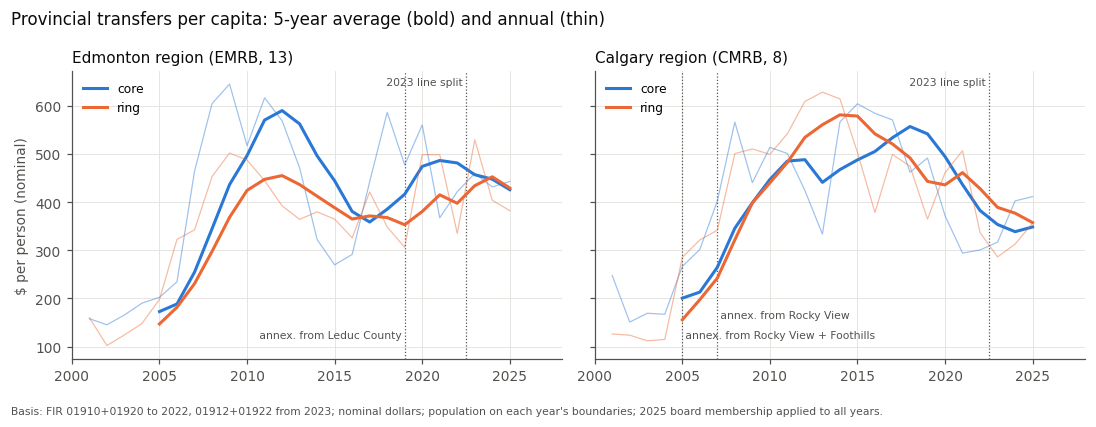

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), sharey=True)
for ax, region in zip(axes, REGIONS):
    d = transfers[(transfers.region == region) & (transfers.level == "side")]
    for role, color in [("core", CORE), ("ring", RING)]:
        s = d[d.role == role].set_index("year")
        ax.plot(s.index, s.per_capita, color=color, lw=0.8, alpha=0.45)
        ax.plot(s.index, s.per_capita_5yr, color=color, lw=2, label=role)
    mark(ax, 2022.5, "2023 line split")
    mark_core_annexations(ax, region)
    ax.set_title(TITLE[region], loc="left", color=INK, fontsize=10)
    ax.set_xlim(2000, 2028)
    ax.legend(loc="upper left", fontsize=8)
axes[0].set_ylabel("$ per person (nominal)")
fig.suptitle("Provincial transfers per capita: 5-year average (bold) and annual (thin)",
             x=0.01, ha="left", color=INK, fontsize=11)
fig.text(0.01, -0.04, "Basis: FIR 01910+01920 to 2022, 01912+01922 from 2023; nominal dollars; "
         "population on each year's boundaries; 2025 board membership applied to all years.",
         fontsize=7, color=MUTED)
fig.tight_layout()

## 3. Operating spending per capita by function, core vs ring

Gross operating cost per capita. FIR switches to accrual in 2009 (expense minus
amortization from then); the step was measured on restated 2008 and is ≤3% for police,
transit and FCSS, so those run through it. Public housing changes scope at 2009 and
starts there.

- **Police ring excludes** members that report no police spending (rural RCMP costs
  aren't in that line): Parkland and Sturgeon (Edmonton), Foothills and Rocky View
  (Calgary), every year; plus the unexplained zeros Devon 2021 and Cochrane 2022.
- **Calgary-core FCSS and housing are not comparable year to year**: Calgary moves amounts
  between FIR function lines (2016, 2020, 2022, probably 2025). The 2022 housing dip and
  FCSS spike are one move, not spending. Edmonton-core FCSS before 2007 is probably on
  another basis. Edmonton-core housing 2021–2023 is real, and 2022 includes a $70.0M
  non-cash transfer to Homeward Trust. `docs/FINDINGS_spending_jumps_2026-10-10.md`.

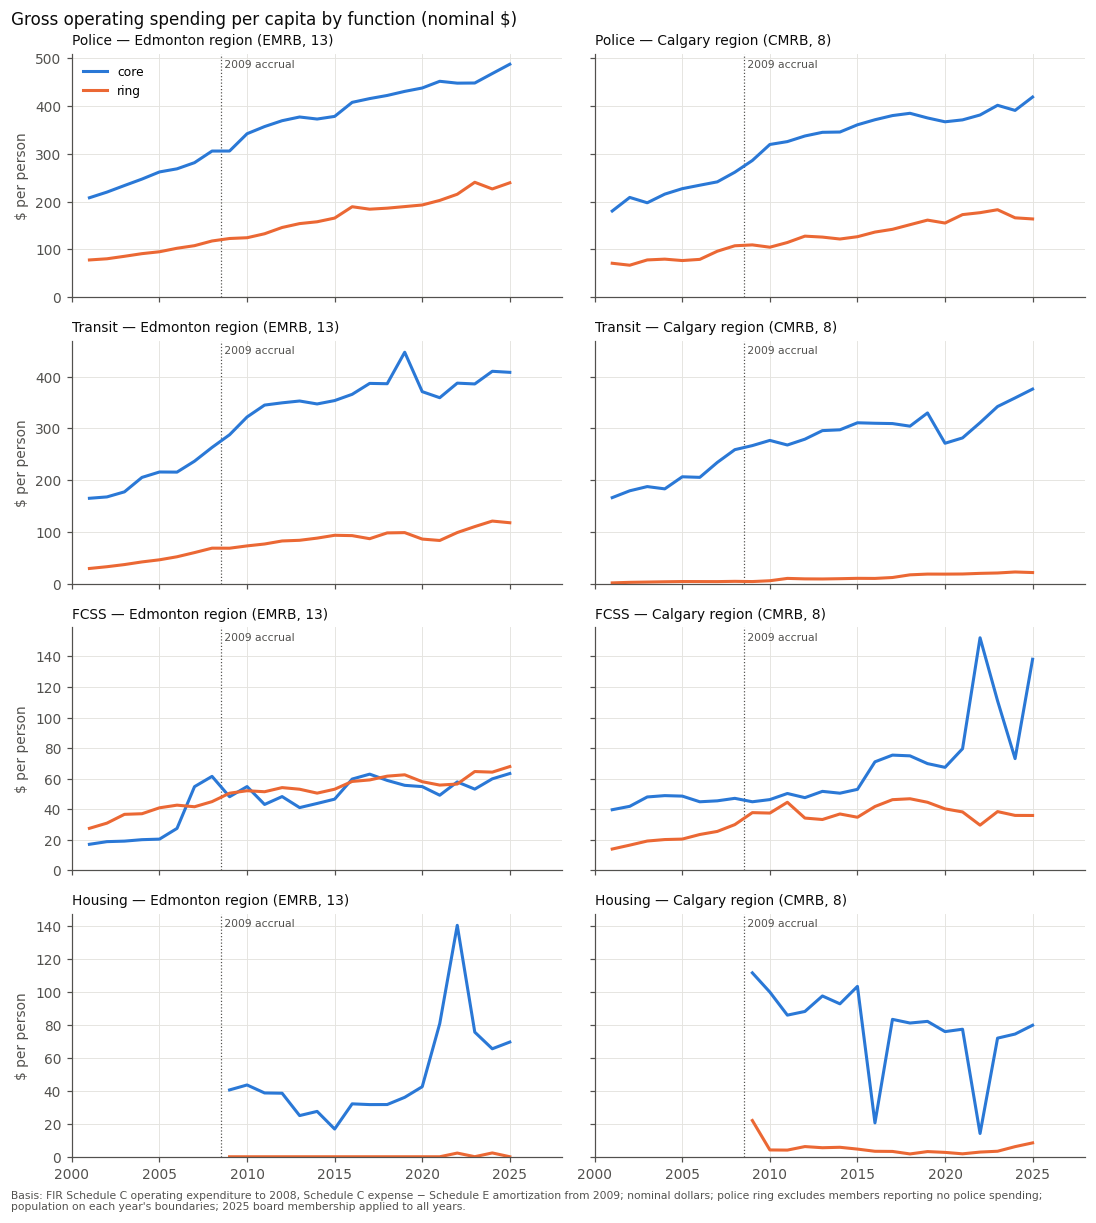

In [6]:
FUNCS = ["police", "transit", "fcss", "housing"]
fig, axes = plt.subplots(len(FUNCS), 2, figsize=(10, 11), sharex=True, sharey="row")
for i, func in enumerate(FUNCS):
    for j, region in enumerate(REGIONS):
        ax = axes[i, j]
        d = spending[(spending.region == region) & (spending.level == "side")
                     & (spending.function == func)]
        for role, color in [("core", CORE), ("ring", RING)]:
            s = d[d.role == role].set_index("year").gross_per_capita
            ax.plot(s.index, s, color=color, label=role)
        mark(ax, 2008.5, "2009 accrual")
        ax.set_title(f"{func.upper() if func == 'fcss' else func.title()} — {TITLE[region]}",
                     loc="left", color=INK, fontsize=9)
        ax.set_xlim(2000, 2028)
    axes[i, 0].set_ylabel("$ per person")
# After both panels of a row are drawn, or the shared row limit freezes on the first.
for ax in axes.flat:
    ax.set_ylim(bottom=0)
axes[0, 0].legend(loc="upper left", fontsize=8)
fig.suptitle("Gross operating spending per capita by function (nominal $)",
             x=0.01, ha="left", color=INK, fontsize=11)
fig.text(0.01, -0.01, "Basis: FIR Schedule C operating expenditure to 2008, Schedule C expense − "
         "Schedule E amortization from 2009; nominal dollars; police ring excludes members "
         "reporting no police spending; population on each year's boundaries; 2025 board "
         "membership applied to all years.", fontsize=7, color=MUTED, wrap=True)
fig.tight_layout()

## 4. Core-to-ring ratio, latest year

Same bases as above. Police ring = reporting members only. Ratio left blank where the
ring spends under $1 per person (Edmonton-ring housing).

In [7]:
last = spending.year.max()
side = spending[(spending.level == "side") & (spending.year == last)]
t = side.pivot_table(index=["function", "region"], columns="role", values="gross_per_capita")
t["core / ring"] = t.core / t.ring
tr = transfers[(transfers.level == "side") & (transfers.year == last)].pivot_table(
    index="region", columns="role", values="per_capita_5yr")
tr["core / ring"] = tr.core / tr.ring
print(f"Gross operating $ per capita, {last} (nominal)")
display(t.round({"core": 0, "ring": 0, "core / ring": 1}).assign(
    **{"core / ring": lambda d: d["core / ring"].where(d.ring >= 1)}))
print(f"Provincial transfers $ per capita, 5-year average ending {last} (nominal)")
display(tr.round({"core": 0, "ring": 0, "core / ring": 2}))

Gross operating $ per capita, 2025 (nominal)


role                core   ring  core / ring
function region                             
fcss     calgary   138.0   36.0          3.9
         edmonton   63.0   68.0          0.9
housing  calgary    80.0    8.0          9.5
         edmonton   70.0    0.0          NaN
police   calgary   419.0  164.0          2.6
         edmonton  487.0  239.0          2.0
transit  calgary   376.0   22.0         17.5
         edmonton  408.0  118.0          3.5

Provincial transfers $ per capita, 5-year average ending 2025 (nominal)


role,core,ring,core / ring
region,,,
calgary,348.0,357.0,0.97
edmonton,426.0,429.0,0.99
